# Models are better than nothing

In [2]:
import numpy as np
from qfso.distributions import discretized_normal_probability, plot_distributions
from qfso.models.statevector import (
    hamming_weight,
    match_first_order,
    match_mmd_optimal,
    mmd_squared,
    sorted_mmd_contributions,
)

In [4]:
def two_norm(p, q):
    return np.sqrt(np.sum((p - q) ** 2))
def one_norm(p, q):
    return np.sum(np.abs(p - q))
def kl_divergence(p, q):
    # Avoid division by zero and log of zero by adding a small constant
    epsilon = 1e-10
    p_safe = p + epsilon
    q_safe = q + epsilon
    return np.sum(p_safe * np.log(p_safe / q_safe))

In [51]:
n = 10
p: np.array = discretized_normal_probability((-2, 5), 2**n)
# plot_distributions(
#     p,
#     labels="target p",
#     title="gaussian",
# )
# extract 100 samples from distribution p and compute sampled distribution p_s
n_samples = 500
samples = np.random.choice(2**n, size=n_samples, p=p)
p_s = np.bincount(samples, minlength=2**n) / len(samples)
# plot_distributions(
#     p_s,
#     labels="sampled p",
#     title="sampled gaussian",
# )

MMD²(p, sampled p) = 0.001376
MMD²(p, first-order) = 0.001618
MMD²(p, q)       = 0.001306
2-norm(p, sampled p) = 0.043203
2-norm(p, first-order) = 0.017874
2-norm(p, q)       = 0.012550
1-norm(p, sampled p) = 0.848851
1-norm(p, first-order) = 0.420971
1-norm(p, q)       = 0.299687
KL(p, sampled p) = 6.085061
KL(p, first-order) = 0.168724
KL(p, q)       = 0.117854


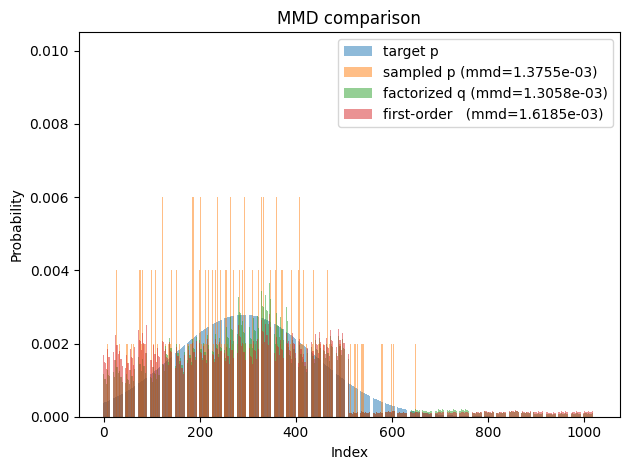

In [52]:
# compute mmd between exact and sampled, and between models and exact and compare

sigma = 0.2 * n
q = match_mmd_optimal(p_s, sigma=sigma, hw_min=1, hw_max=3)
f = np.asarray(match_first_order(p_s))

#mmd
mmd_ps = mmd_squared(p, p_s, sigma)
mmd_pf = mmd_squared(p, f, sigma)
mmd_pq = mmd_squared(p, q, sigma)

#two-norm
two_ps = two_norm(p, p_s)
two_pf = two_norm(p, f)
two_pq = two_norm(p, q)

#one-norm
one_ps = one_norm(p, p_s)
one_pf = one_norm(p, f)
one_pq = one_norm(p, q)

#kl-divergence
kl_ps = kl_divergence(p, p_s)
kl_pf = kl_divergence(p, f)
kl_pq = kl_divergence(p, q)


print(f"MMD²(p, sampled p) = {mmd_ps:.6f}")
print(f"MMD²(p, first-order) = {mmd_pf:.6f}")
print(f"MMD²(p, q)       = {mmd_pq:.6f}")

print(f"2-norm(p, sampled p) = {two_ps:.6f}")
print(f"2-norm(p, first-order) = {two_pf:.6f}")
print(f"2-norm(p, q)       = {two_pq:.6f}")

print(f"1-norm(p, sampled p) = {one_ps:.6f}")
print(f"1-norm(p, first-order) = {one_pf:.6f}")
print(f"1-norm(p, q)       = {one_pq:.6f}")

print(f"KL(p, sampled p) = {kl_ps:.6f}")
print(f"KL(p, first-order) = {kl_pf:.6f}")
print(f"KL(p, q)       = {kl_pq:.6f}")

plot_distributions(
    [p, 
     p_s, 
     q, 
     f
     ],
    labels=[
        "target p", 
        f"sampled p (mmd={mmd_ps:.4e})", 
        f"factorized q (mmd={mmd_pq:.4e})", 
        f"first-order   (mmd={mmd_pf:.4e})"
        ],
    title=f"MMD comparison",
)

# contributions = sorted_mmd_contributions(p, sigma=sigma, hw_min=1, hw_max=3)
# print("\nTop MMD contributions:")
# for k, contrib, c in contributions[:10]:
#     print(f"  k={k:0{n}b}  hw={hamming_weight(k)}  w*ĉ²={contrib:.6f}  ĉ={c:.4f}")


## Scaling plots

Con gaussiana
1) plot iniziale
2) metriche, tutte, fissati sample, variare di n_qubits, hue: dist piccata e non piccata centrata non centrata
2) metriche, tutte, fissati n_qubits, variare di sample, hue: dist piccata e non piccata centrata non centrata

Con distribuzione fattorizzata fittata con le due:
same

### Gaussian fixed qubits

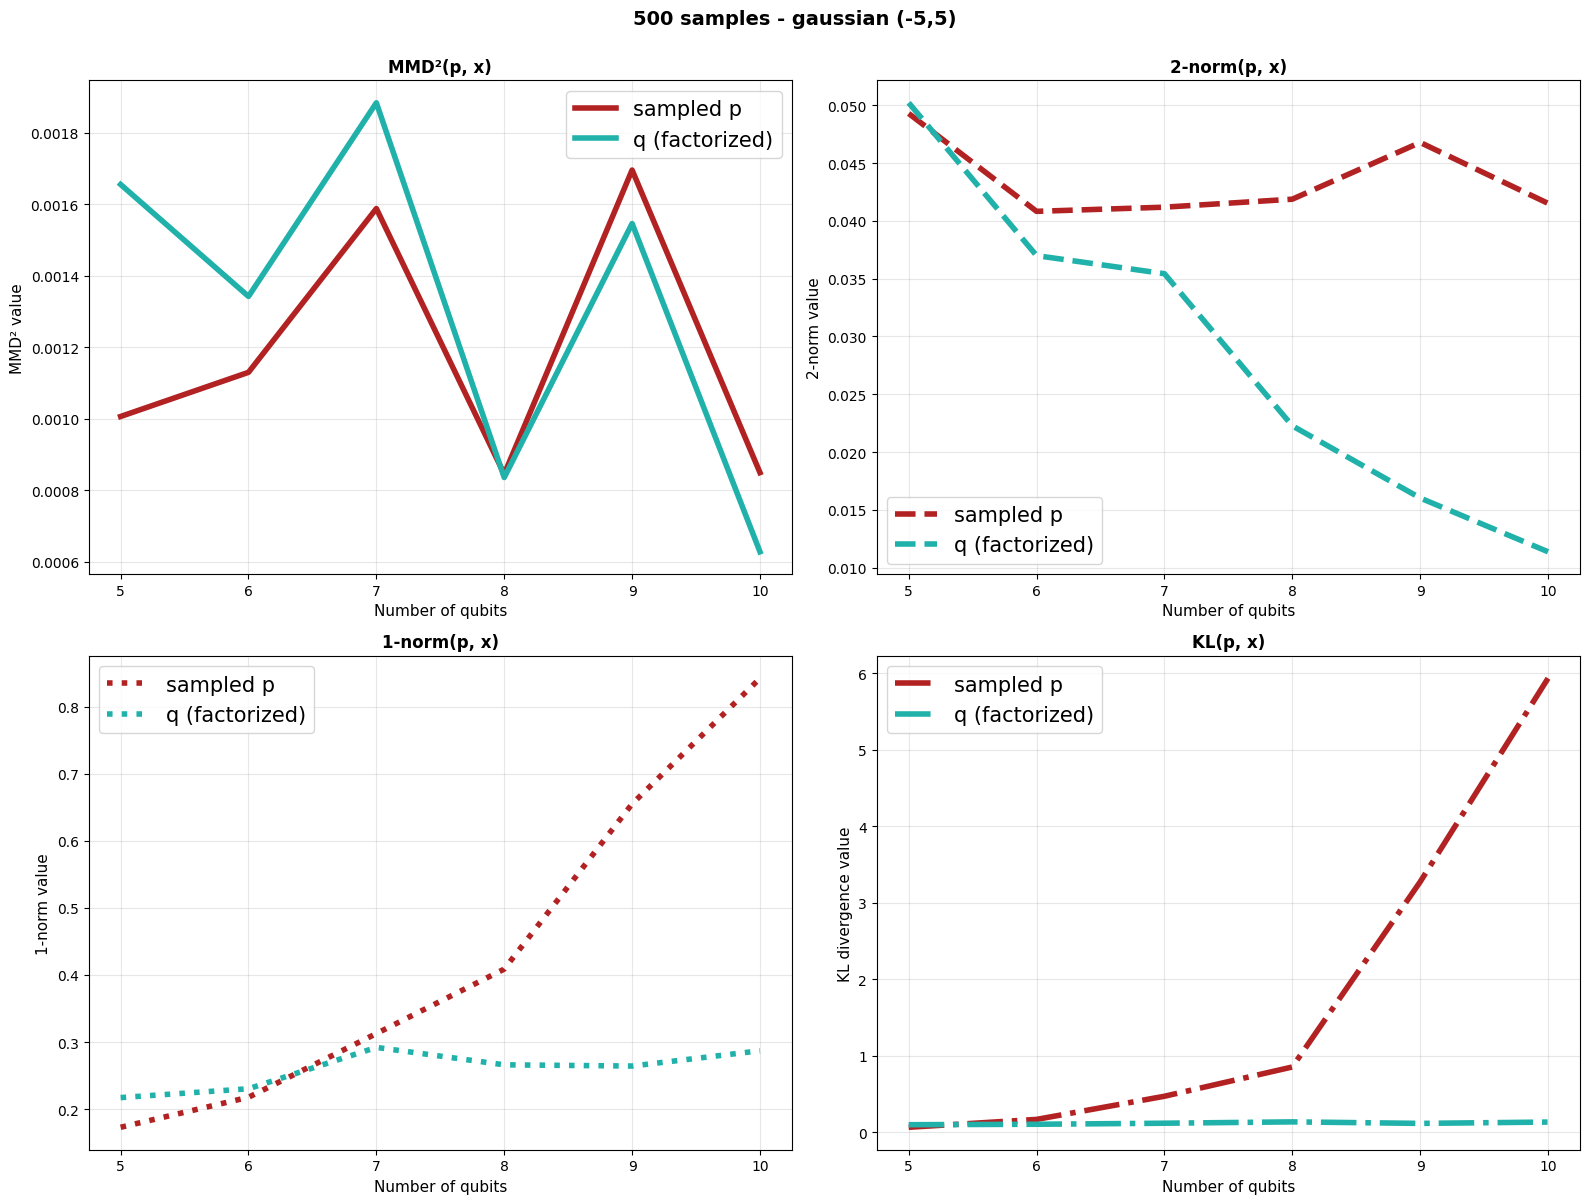

In [46]:
n_samples = 500
min_qubits = 5
max_qubits = 10

mmd_ps_list = []
mmd_pf_list = []
mmd_pq_list = []

two_ps_list = []
two_pf_list = []
two_pq_list = []

one_ps_list = []
one_pf_list = []
one_pq_list = []

kl_ps_list = []
kl_pf_list = []
kl_pq_list = []

for n in range(min_qubits, max_qubits+1):
    p: np.array = discretized_normal_probability((-2, 5), 2**n)

    samples = np.random.default_rng().choice(2**n, size=n_samples, p=p)
    p_s = np.bincount(samples, minlength=2**n) / len(samples)

    q = match_mmd_optimal(p_s, sigma=0.2*n, hw_min=1, hw_max=3)
    f = np.asarray(match_first_order(p_s))
    
    mmd_ps_list.append(mmd_squared(p, p_s, sigma=0.2*n))
    mmd_pf_list.append(mmd_squared(p, f, sigma=0.2*n))
    mmd_pq_list.append(mmd_squared(p, q, sigma=0.2*n))

    two_ps_list.append(two_norm(p, p_s))
    two_pf_list.append(two_norm(p, f))
    two_pq_list.append(two_norm(p, q))

    one_ps_list.append(one_norm(p, p_s))
    one_pf_list.append(one_norm(p, f))
    one_pq_list.append(one_norm(p, q))

    kl_ps_list.append(kl_divergence(p, p_s))
    kl_pf_list.append(kl_divergence(p, f))
    kl_pq_list.append(kl_divergence(p, q))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

line_styles = {
    'mmd': 'solid',
    'two_norm': 'dashed',
    'one_norm': 'dotted',
    'kl': 'dashdot',
}
colors = {
    'ps': 'firebrick',
    'pq': 'lightseagreen',
    'pf': 'slateblue',
}
line_width = 4

# MMD plot
axes[0, 0].plot(range(min_qubits, max_qubits+1), mmd_ps_list, label="sampled p", 
         linestyle=line_styles['mmd'], color=colors['ps'], linewidth=line_width)
axes[0, 0].plot(range(min_qubits, max_qubits+1), mmd_pq_list, label="q (factorized)", 
         linestyle=line_styles['mmd'], color=colors['pq'], linewidth=line_width)
# axes[0, 0].plot(range(min_qubits, max_qubits+1), mmd_pf_list, label="f (first-order)", 
#          linestyle=line_styles['mmd'], color=colors['pf'], linewidth=line_width)

axes[0, 0].set_xlabel("Number of qubits", fontsize=11)
axes[0, 0].set_ylabel("MMD² value", fontsize=11)
axes[0, 0].set_title("MMD²(p, x)", fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=15)
axes[0, 0].grid(alpha=0.3)

# 2-norm plot
axes[0, 1].plot(range(min_qubits, max_qubits+1), two_ps_list, label="sampled p", 
         linestyle=line_styles['two_norm'], color=colors['ps'], linewidth=line_width)
axes[0, 1].plot(range(min_qubits, max_qubits+1), two_pq_list, label="q (factorized)", 
         linestyle=line_styles['two_norm'], color=colors['pq'], linewidth=line_width)
# axes[0, 1].plot(range(min_qubits, max_qubits+1), two_pf_list, label="f (first-order)", 
#          linestyle=line_styles['two_norm'], color=colors['pf'], linewidth=line_width)

axes[0, 1].set_xlabel("Number of qubits", fontsize=11)
axes[0, 1].set_ylabel("2-norm value", fontsize=11)
axes[0, 1].set_title("2-norm(p, x)", fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=15)
axes[0, 1].grid(alpha=0.3)

# 1-norm plot
axes[1, 0].plot(range(min_qubits, max_qubits+1), one_ps_list, label="sampled p", 
         linestyle=line_styles['one_norm'], color=colors['ps'], linewidth=line_width)
axes[1, 0].plot(range(min_qubits, max_qubits+1), one_pq_list, label="q (factorized)", 
         linestyle=line_styles['one_norm'], color=colors['pq'], linewidth=line_width)
# axes[1, 0].plot(range(min_qubits, max_qubits+1), one_pf_list, label="f (first-order)", 
#          linestyle=line_styles['one_norm'], color=colors['pf'], linewidth=line_width)

axes[1, 0].set_xlabel("Number of qubits", fontsize=11)
axes[1, 0].set_ylabel("1-norm value", fontsize=11)
axes[1, 0].set_title("1-norm(p, x)", fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=15)
axes[1, 0].grid(alpha=0.3)

# KL divergence plot
axes[1, 1].plot(range(min_qubits, max_qubits+1), kl_ps_list, label="sampled p", 
         linestyle=line_styles['kl'], color=colors['ps'], linewidth=line_width)
axes[1, 1].plot(range(min_qubits, max_qubits+1), kl_pq_list, label="q (factorized)", 
         linestyle=line_styles['kl'], color=colors['pq'], linewidth=line_width)
# axes[1, 1].plot(range(min_qubits, max_qubits+1), kl_pf_list, label="f (first-order)", 
#          linestyle=line_styles['kl'], color=colors['pf'], linewidth=line_width)

axes[1, 1].set_xlabel("Number of qubits", fontsize=11)
axes[1, 1].set_ylabel("KL divergence value", fontsize=11)
axes[1, 1].set_title("KL(p, x)", fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=15)
axes[1, 1].grid(alpha=0.3)

plt.suptitle("500 samples - gaussian (-5,5)", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Gaussian fixed samples

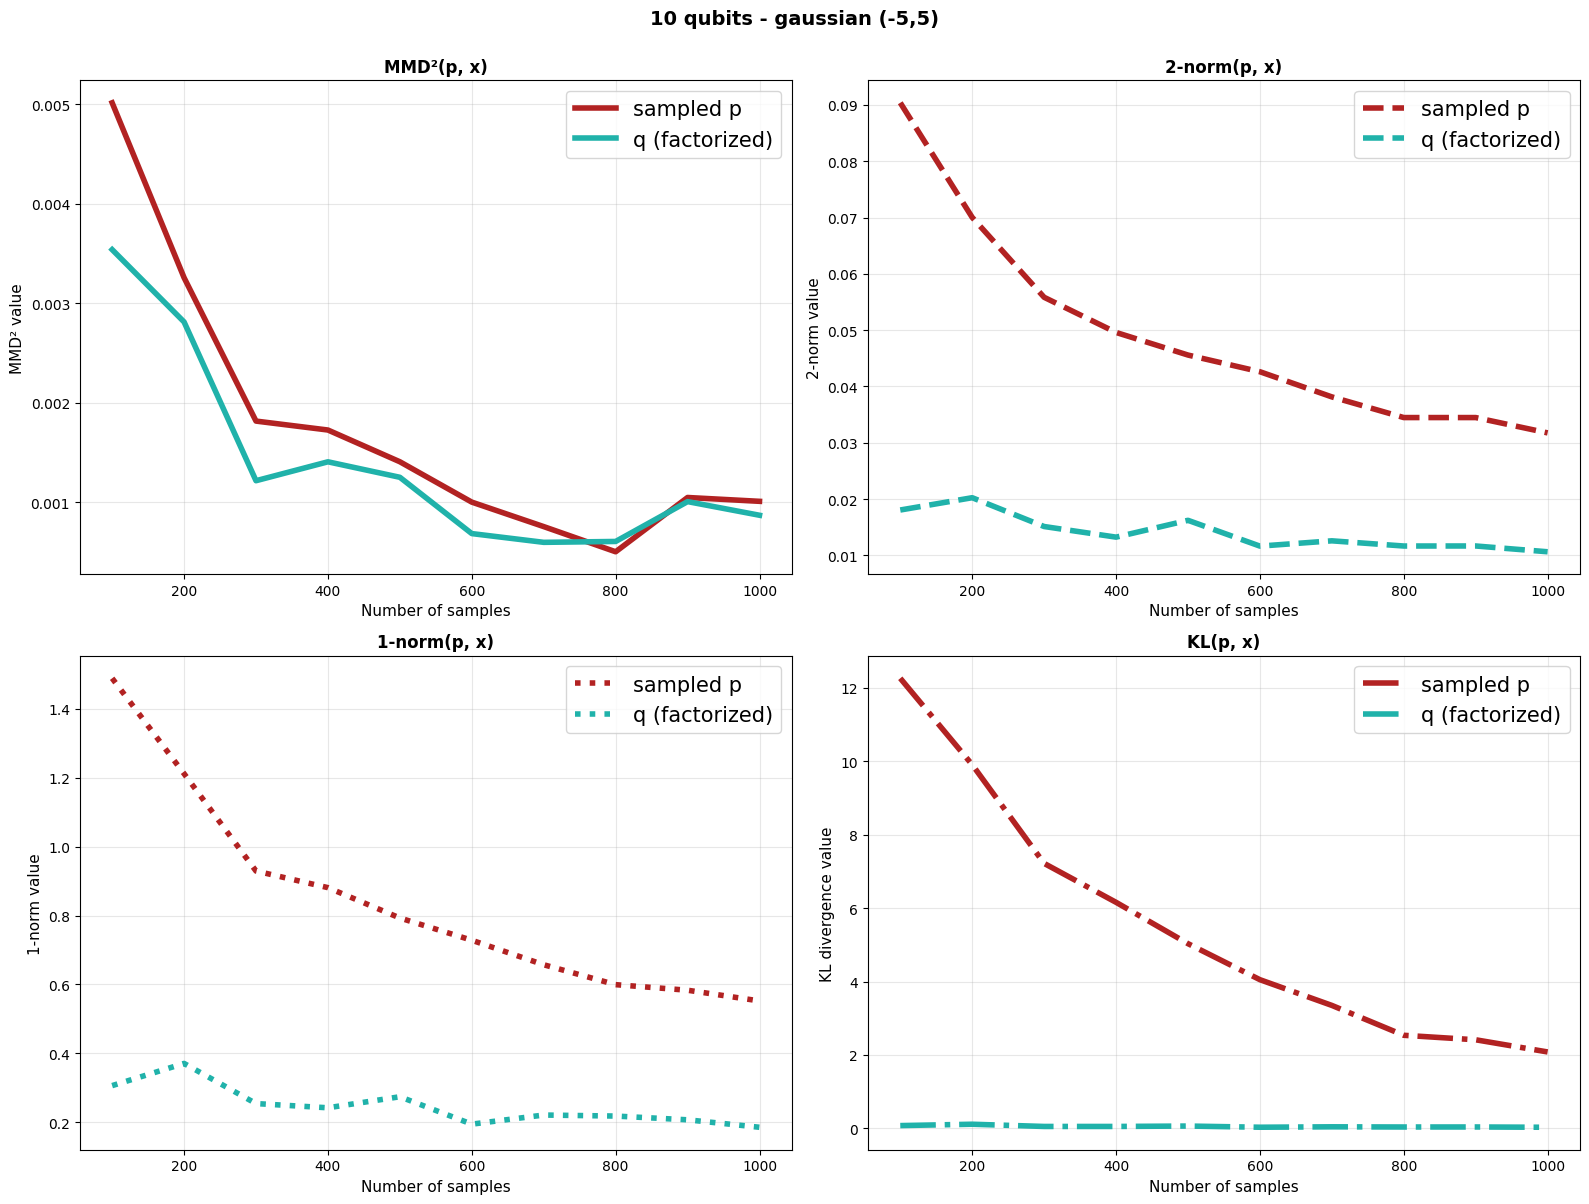

In [40]:
n_qubits = 10
min_samples = 100
max_samples = 1000

mmd_ps_list = []
mmd_pf_list = []
mmd_pq_list = []

two_ps_list = []
two_pf_list = []
two_pq_list = []

one_ps_list = []
one_pf_list = []
one_pq_list = []

kl_ps_list = []
kl_pf_list = []
kl_pq_list = []

for s in range(min_samples, max_samples+1, 100):
    p: np.array = discretized_normal_probability((-5, 5), 2**n_qubits)

    samples = np.random.default_rng().choice(2**n_qubits, size=s, p=p)
    p_s = np.bincount(samples, minlength=2**n_qubits) / len(samples)

    q = match_mmd_optimal(p_s, sigma=0.2*n_qubits, hw_min=1, hw_max=3)
    f = np.asarray(match_first_order(p_s))
    
    mmd_ps_list.append(mmd_squared(p, p_s, sigma=0.2*n_qubits))
    mmd_pf_list.append(mmd_squared(p, f, sigma=0.2*n_qubits))
    mmd_pq_list.append(mmd_squared(p, q, sigma=0.2*n_qubits))

    two_ps_list.append(two_norm(p, p_s))
    two_pf_list.append(two_norm(p, f))
    two_pq_list.append(two_norm(p, q))

    one_ps_list.append(one_norm(p, p_s))
    one_pf_list.append(one_norm(p, f))
    one_pq_list.append(one_norm(p, q))

    kl_ps_list.append(kl_divergence(p, p_s))
    kl_pf_list.append(kl_divergence(p, f))
    kl_pq_list.append(kl_divergence(p, q))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

line_styles = {
    'mmd': 'solid',
    'two_norm': 'dashed',
    'one_norm': 'dotted',
    'kl': 'dashdot',
}
colors = {
    'ps': 'firebrick',
    'pq': 'lightseagreen',
    'pf': 'slateblue',
}
line_width = 4

# MMD plot
axes[0, 0].plot(range(min_samples, max_samples+1, 100), mmd_ps_list, label="sampled p", 
         linestyle=line_styles['mmd'], color=colors['ps'], linewidth=line_width)
axes[0, 0].plot(range(min_samples, max_samples+1, 100), mmd_pq_list, label="q (factorized)", 
         linestyle=line_styles['mmd'], color=colors['pq'], linewidth=line_width)
# axes[0, 0].plot(range(min_samples, max_samples+1, 100), mmd_pf_list, label="f (first-order)", 
#          linestyle=line_styles['mmd'], color=colors['pf'], linewidth=line_width)

axes[0, 0].set_xlabel("Number of samples", fontsize=11)
axes[0, 0].set_ylabel("MMD² value", fontsize=11)
axes[0, 0].set_title("MMD²(p, x)", fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=15)
axes[0, 0].grid(alpha=0.3)

# 2-norm plot
axes[0, 1].plot(range(min_samples, max_samples+1, 100), two_ps_list, label="sampled p", 
         linestyle=line_styles['two_norm'], color=colors['ps'], linewidth=line_width)
axes[0, 1].plot(range(min_samples, max_samples+1, 100), two_pq_list, label="q (factorized)", 
         linestyle=line_styles['two_norm'], color=colors['pq'], linewidth=line_width)
# axes[0, 1].plot(range(min_samples, max_samples+1, 100), two_pf_list, label="f (first-order)", 
#          linestyle=line_styles['two_norm'], color=colors['pf'], linewidth=line_width)

axes[0, 1].set_xlabel("Number of samples", fontsize=11)
axes[0, 1].set_ylabel("2-norm value", fontsize=11)
axes[0, 1].set_title("2-norm(p, x)", fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=15)
axes[0, 1].grid(alpha=0.3)

# 1-norm plot
axes[1, 0].plot(range(min_samples, max_samples+1, 100), one_ps_list, label="sampled p", 
         linestyle=line_styles['one_norm'], color=colors['ps'], linewidth=line_width)
axes[1, 0].plot(range(min_samples, max_samples+1, 100), one_pq_list, label="q (factorized)", 
         linestyle=line_styles['one_norm'], color=colors['pq'], linewidth=line_width)
# axes[1, 0].plot(range(min_samples, max_samples+1, 100), one_pf_list, label="f (first-order)", 
#          linestyle=line_styles['one_norm'], color=colors['pf'], linewidth=line_width)

axes[1, 0].set_xlabel("Number of samples", fontsize=11)
axes[1, 0].set_ylabel("1-norm value", fontsize=11)
axes[1, 0].set_title("1-norm(p, x)", fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=15)
axes[1, 0].grid(alpha=0.3)

# KL divergence plot
axes[1, 1].plot(range(min_samples, max_samples+1, 100), kl_ps_list, label="sampled p", 
         linestyle=line_styles['kl'], color=colors['ps'], linewidth=line_width)
axes[1, 1].plot(range(min_samples, max_samples+1, 100), kl_pq_list, label="q (factorized)", 
         linestyle=line_styles['kl'], color=colors['pq'], linewidth=line_width)
# axes[1, 1].plot(range(min_samples, max_samples+1, 100), kl_pf_list, label="f (first-order)", 
#          linestyle=line_styles['kl'], color=colors['pf'], linewidth=line_width)

axes[1, 1].set_xlabel("Number of samples", fontsize=11)
axes[1, 1].set_ylabel("KL divergence value", fontsize=11)
axes[1, 1].set_title("KL(p, x)", fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=15)
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f"{n_qubits} qubits - gaussian (-5,5)", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Factorized fixed qubits

same but we fit p with match_optimal and we assum that as the new p

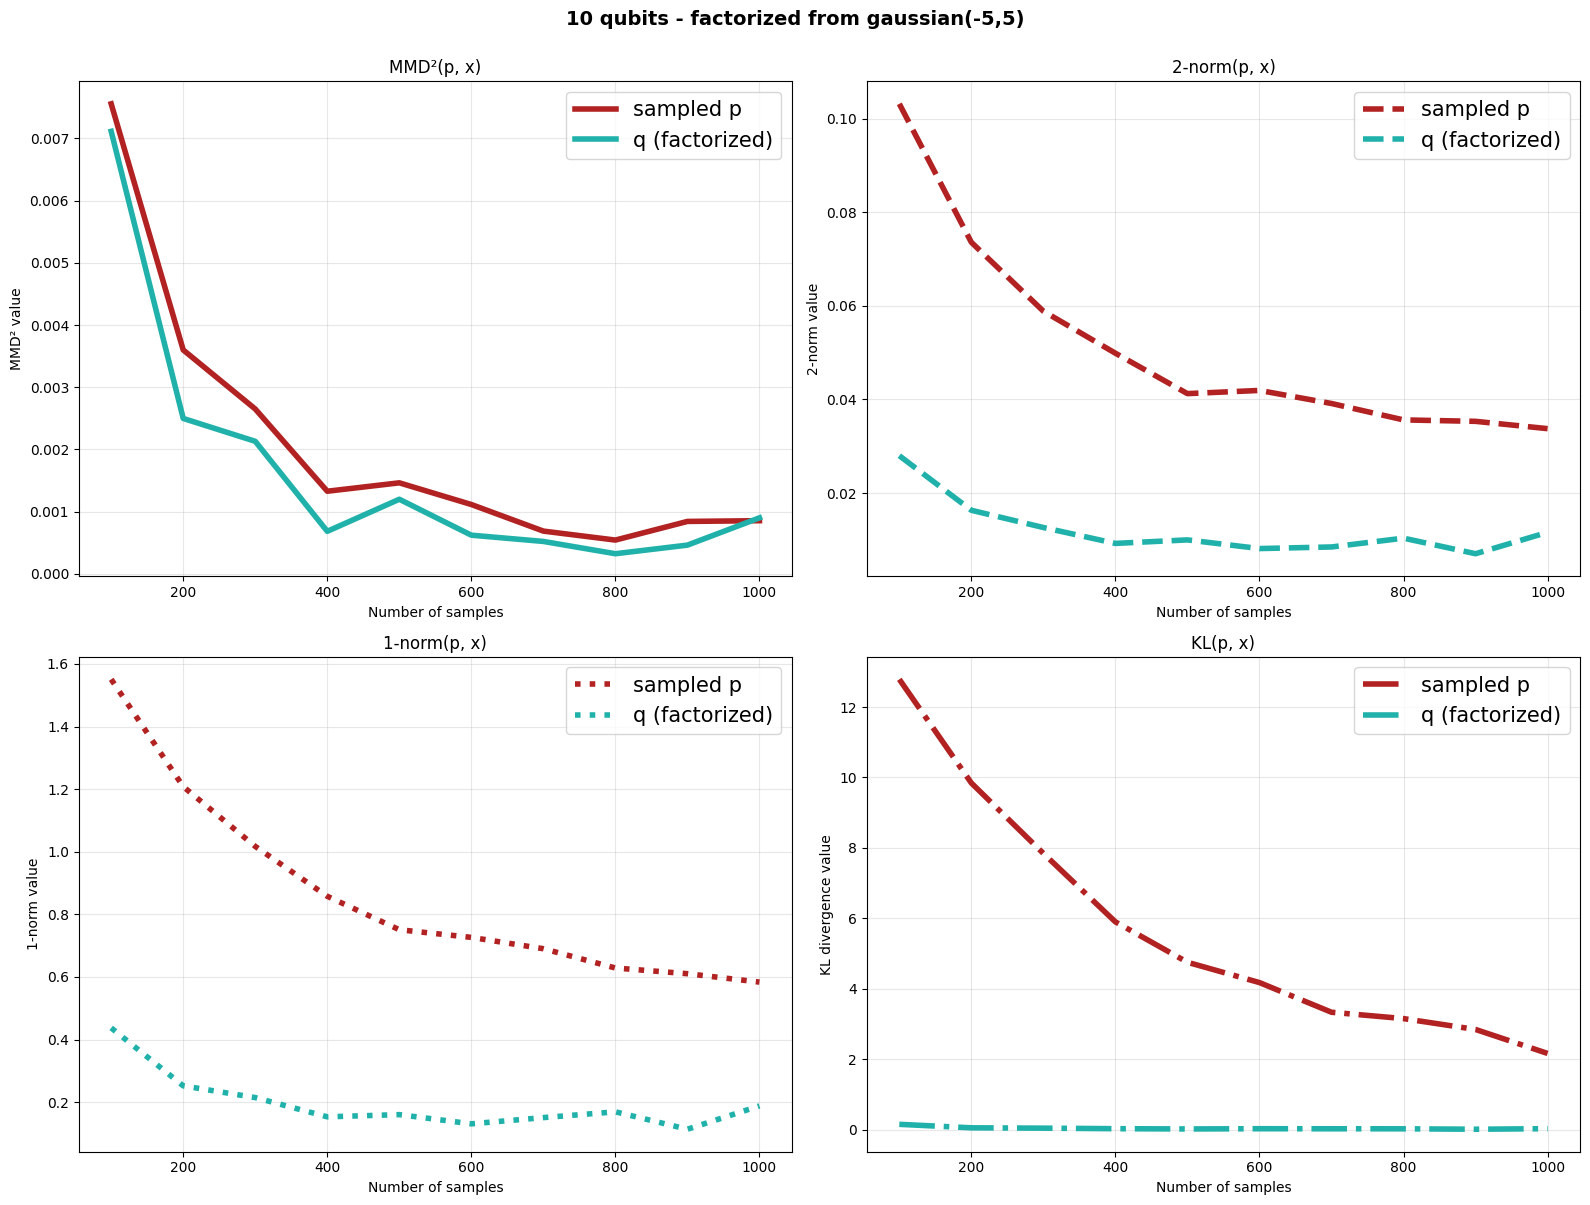

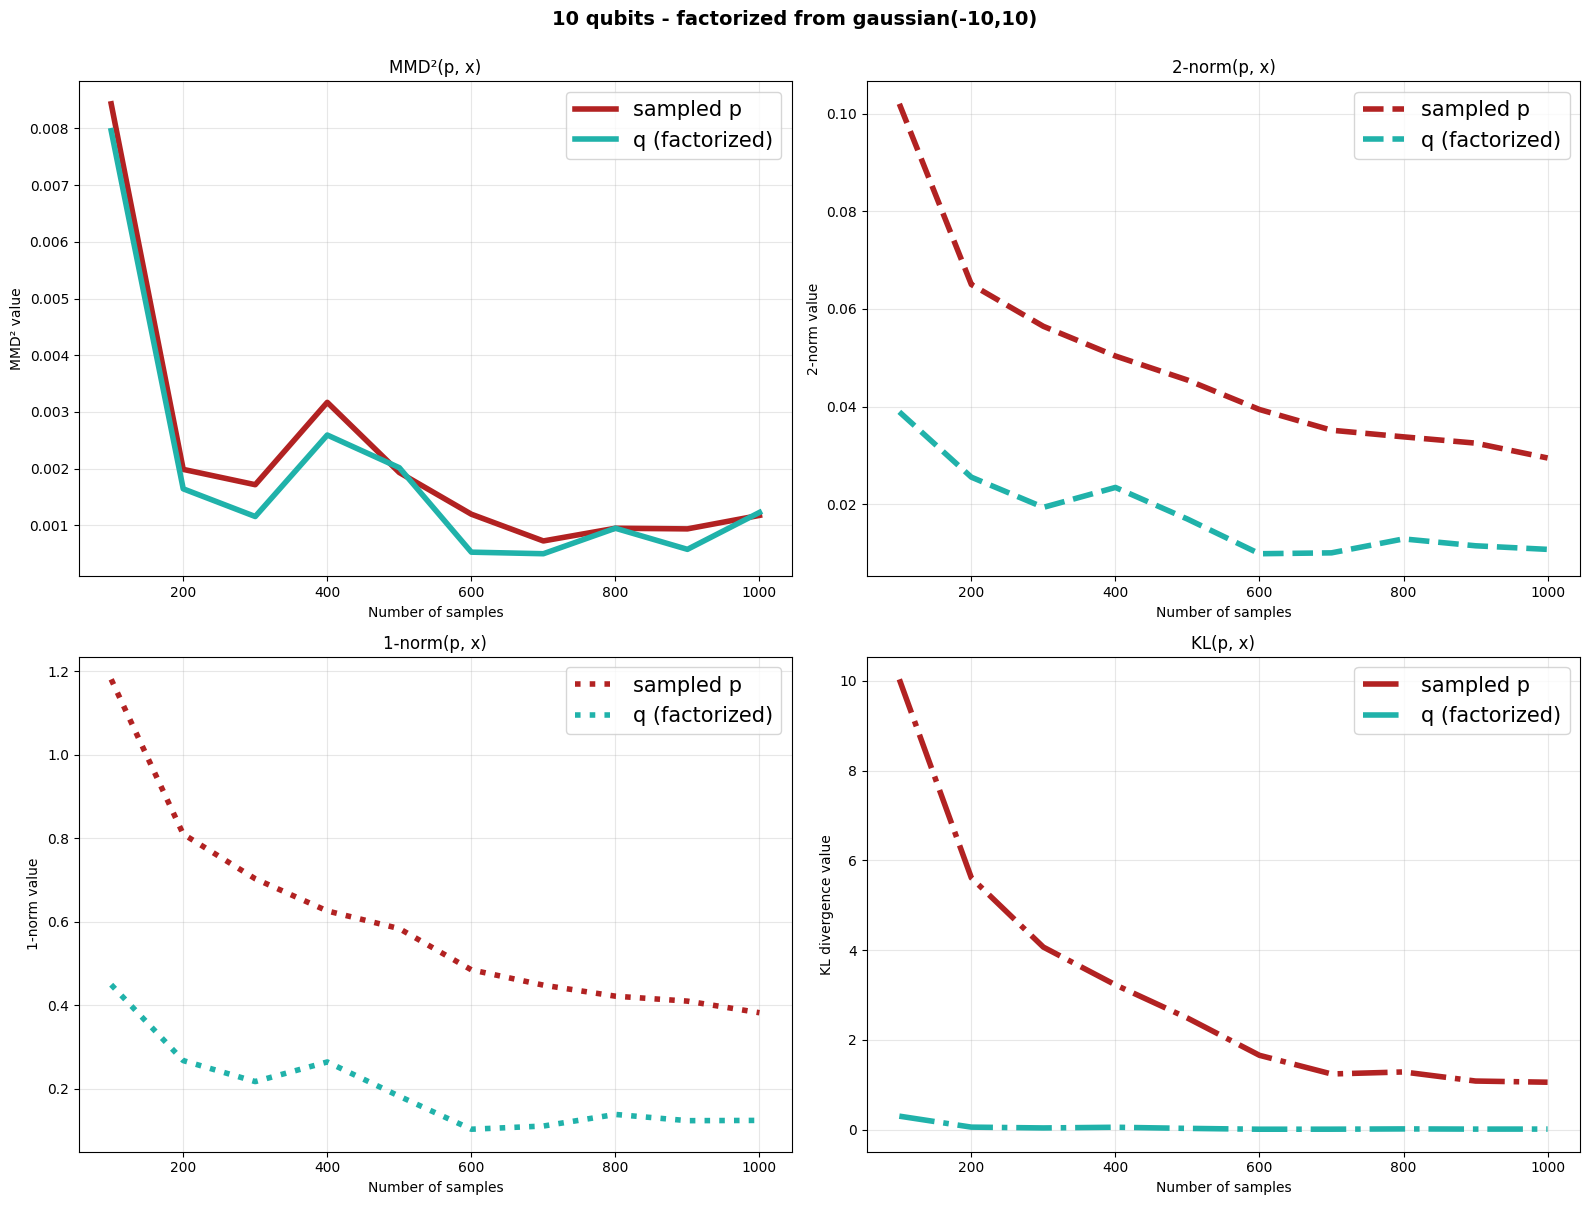

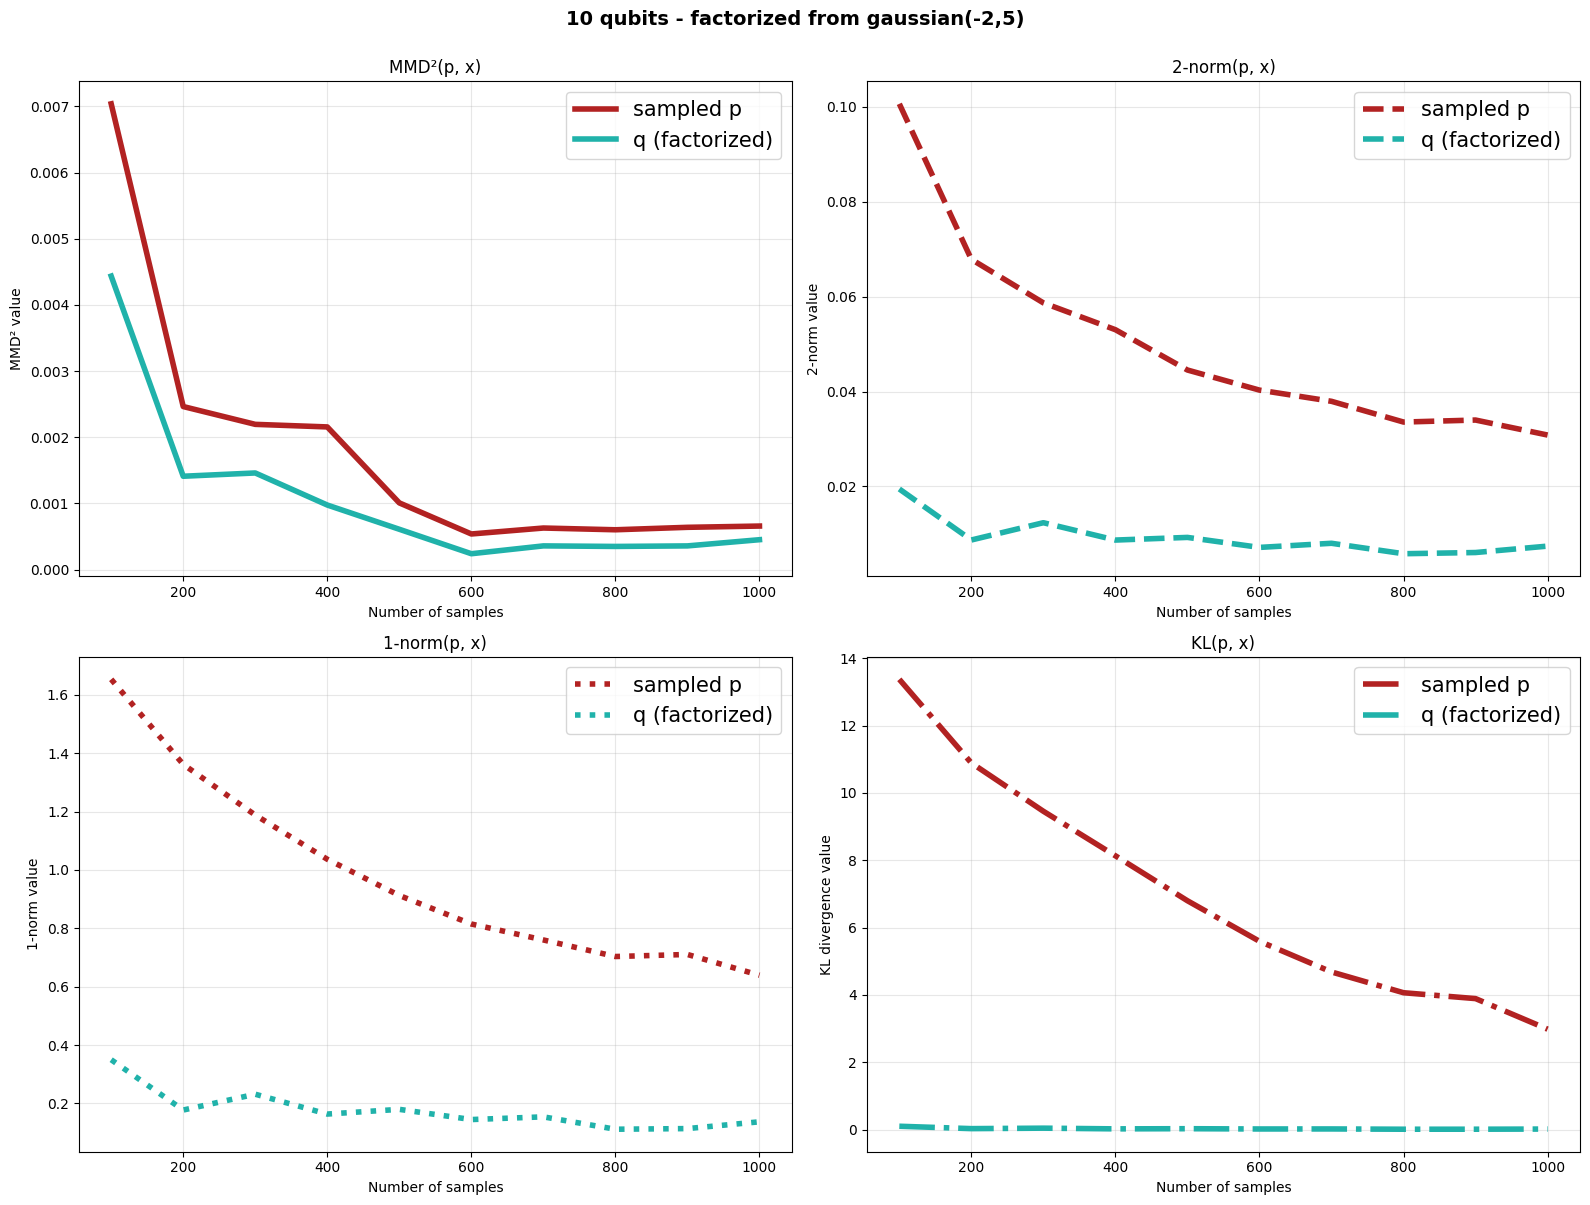

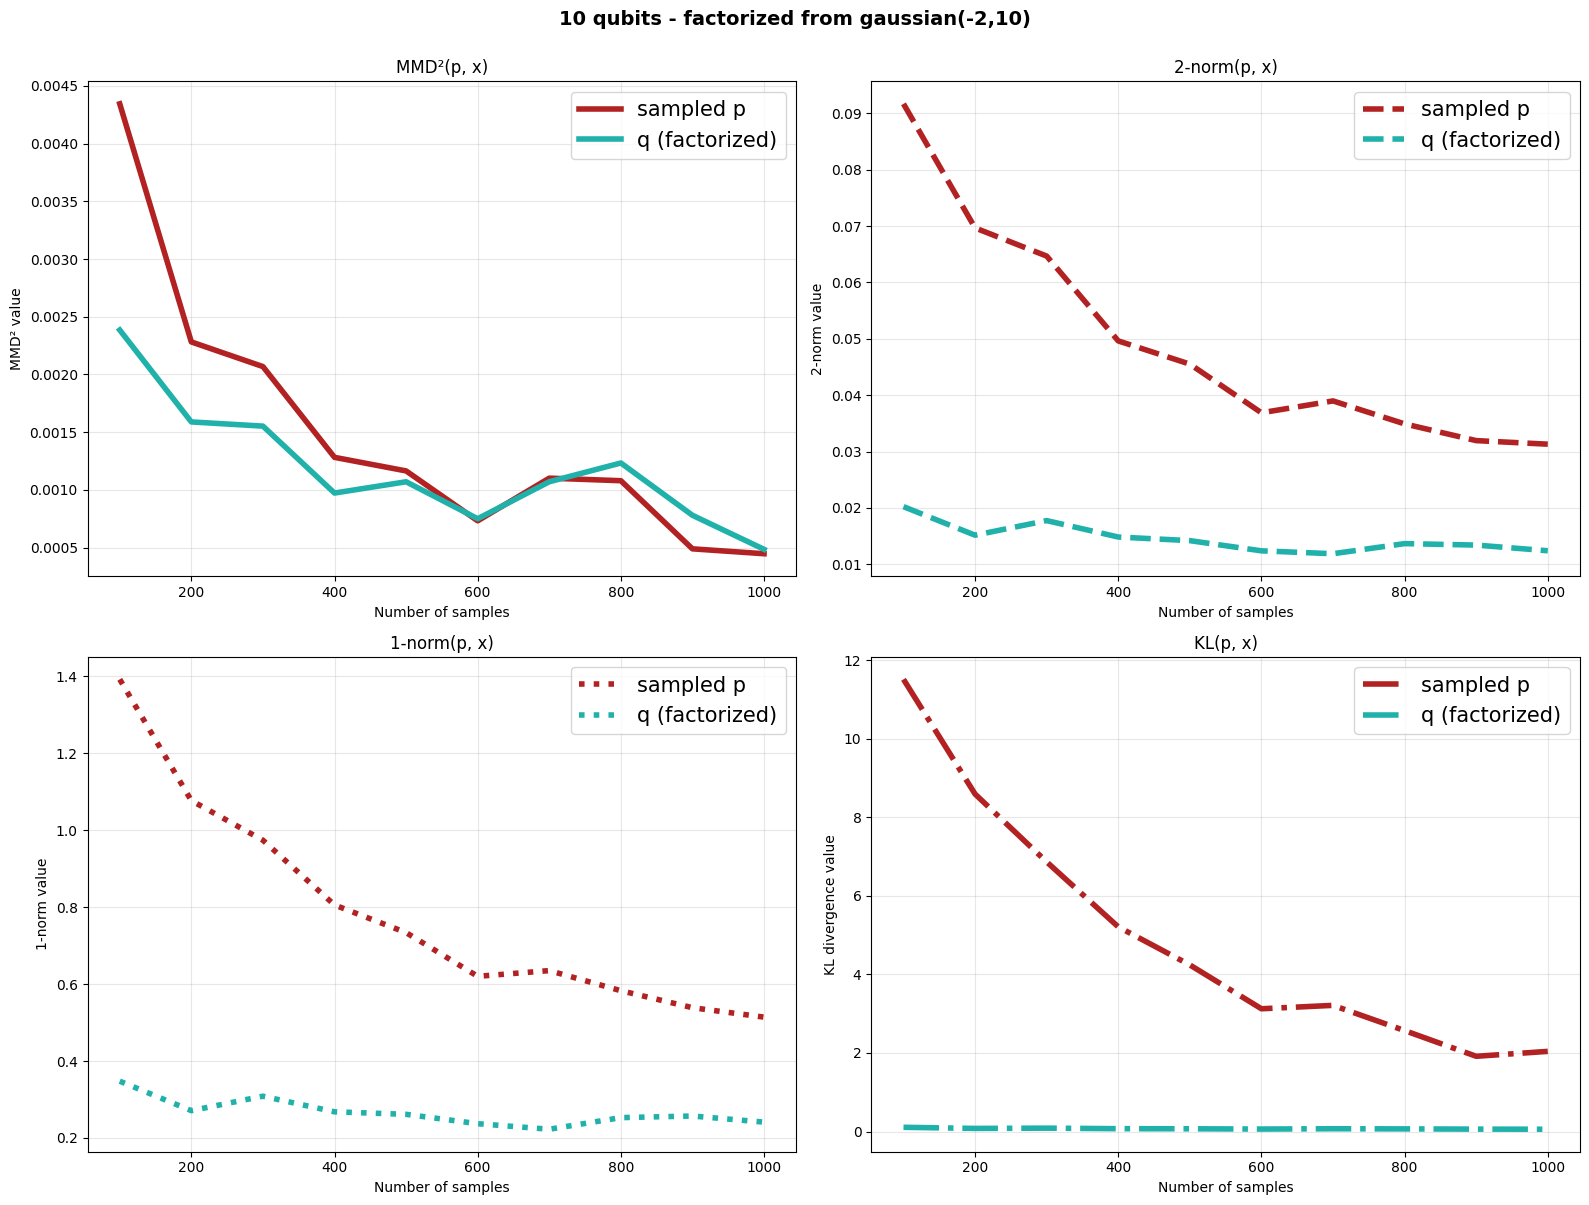

In [47]:
intervals = [(-5, 5), (-10, 10), (-2, 5), (-2, 10)]
n_qubits = 10
min_samples = 100
max_samples = 1000

for interval in intervals:
    mmd_ps_list = []
    mmd_pf_list = []
    mmd_pq_list = []

    two_ps_list = []
    two_pf_list = []
    two_pq_list = []

    one_ps_list = []
    one_pf_list = []
    one_pq_list = []

    kl_ps_list = []
    kl_pf_list = []
    kl_pq_list = []

    for s in range(min_samples, max_samples + 1, 100):
        p = discretized_normal_probability(interval, 2**n_qubits)
        p = match_mmd_optimal(
            p,
            sigma=0.2 * n_qubits,
            hw_min=1,
            hw_max=3
        )

        samples = np.random.default_rng().choice(
            2**n_qubits,
            size=s,
            p=p
        )
        p_s = np.bincount(samples, minlength=2**n_qubits) / len(samples)

        q = match_mmd_optimal(
            p_s,
            sigma=0.2 * n_qubits,
            hw_min=1,
            hw_max=3
        )
        f = np.asarray(match_first_order(p_s))

        mmd_ps_list.append(mmd_squared(p, p_s, sigma=0.2*n_qubits))
        mmd_pf_list.append(mmd_squared(p, f, sigma=0.2*n_qubits))
        mmd_pq_list.append(mmd_squared(p, q, sigma=0.2*n_qubits))

        two_ps_list.append(two_norm(p, p_s))
        two_pf_list.append(two_norm(p, f))
        two_pq_list.append(two_norm(p, q))

        one_ps_list.append(one_norm(p, p_s))
        one_pf_list.append(one_norm(p, f))
        one_pq_list.append(one_norm(p, q))

        kl_ps_list.append(kl_divergence(p, p_s))
        kl_pf_list.append(kl_divergence(p, f))
        kl_pq_list.append(kl_divergence(p, q))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    x = range(min_samples, max_samples + 1, 100)

    # MMD
    axes[0, 0].plot(x, mmd_ps_list, label="sampled p",
                    linestyle=line_styles['mmd'],
                    color=colors['ps'],
                    linewidth=line_width)
    axes[0, 0].plot(x, mmd_pq_list, label="q (factorized)",
                    linestyle=line_styles['mmd'],
                    color=colors['pq'],
                    linewidth=line_width)
    axes[0, 0].set_xlabel("Number of samples")
    axes[0, 0].set_ylabel("MMD² value")
    axes[0, 0].set_title("MMD²(p, x)")
    axes[0, 0].legend(fontsize=15)
    axes[0, 0].grid(alpha=0.3)

    # 2-norm
    axes[0, 1].plot(x, two_ps_list, label="sampled p",
                    linestyle=line_styles['two_norm'],
                    color=colors['ps'],
                    linewidth=line_width)
    axes[0, 1].plot(x, two_pq_list, label="q (factorized)",
                    linestyle=line_styles['two_norm'],
                    color=colors['pq'],
                    linewidth=line_width)
    axes[0, 1].set_xlabel("Number of samples")
    axes[0, 1].set_ylabel("2-norm value")
    axes[0, 1].set_title("2-norm(p, x)")
    axes[0, 1].legend(fontsize=15)
    axes[0, 1].grid(alpha=0.3)

    # 1-norm
    axes[1, 0].plot(x, one_ps_list, label="sampled p",
                    linestyle=line_styles['one_norm'],
                    color=colors['ps'],
                    linewidth=line_width)
    axes[1, 0].plot(x, one_pq_list, label="q (factorized)",
                    linestyle=line_styles['one_norm'],
                    color=colors['pq'],
                    linewidth=line_width)
    axes[1, 0].set_xlabel("Number of samples")
    axes[1, 0].set_ylabel("1-norm value")
    axes[1, 0].set_title("1-norm(p, x)")
    axes[1, 0].legend(fontsize=15)
    axes[1, 0].grid(alpha=0.3)

    # KL
    axes[1, 1].plot(x, kl_ps_list, label="sampled p",
                    linestyle=line_styles['kl'],
                    color=colors['ps'],
                    linewidth=line_width)
    axes[1, 1].plot(x, kl_pq_list, label="q (factorized)",
                    linestyle=line_styles['kl'],
                    color=colors['pq'],
                    linewidth=line_width)
    axes[1, 1].set_xlabel("Number of samples")
    axes[1, 1].set_ylabel("KL divergence value")
    axes[1, 1].set_title("KL(p, x)")
    axes[1, 1].legend(fontsize=15)
    axes[1, 1].grid(alpha=0.3)

    a, b = interval
    plt.suptitle(
        f"{n_qubits} qubits - factorized from gaussian({a},{b})",
        fontsize=14,
        fontweight='bold',
        y=1.00
    )
    plt.tight_layout()
    plt.savefig(f"sampling_exp_{a}_{b}.png")

### factorized - fix qubits

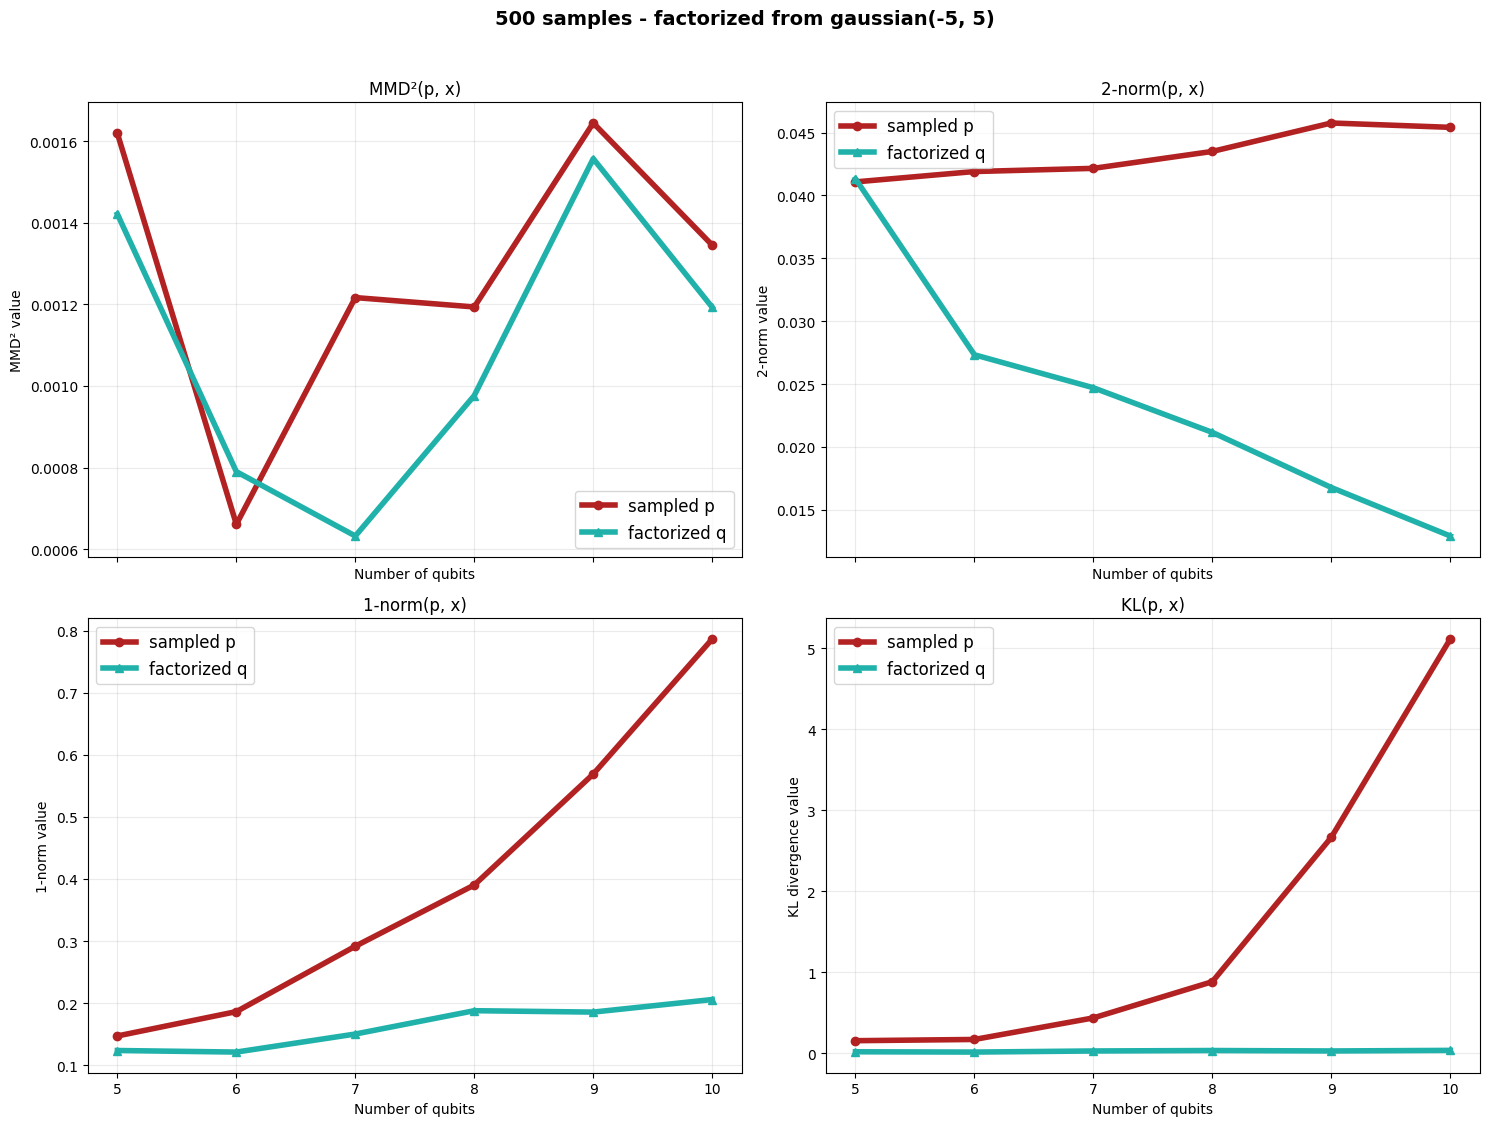

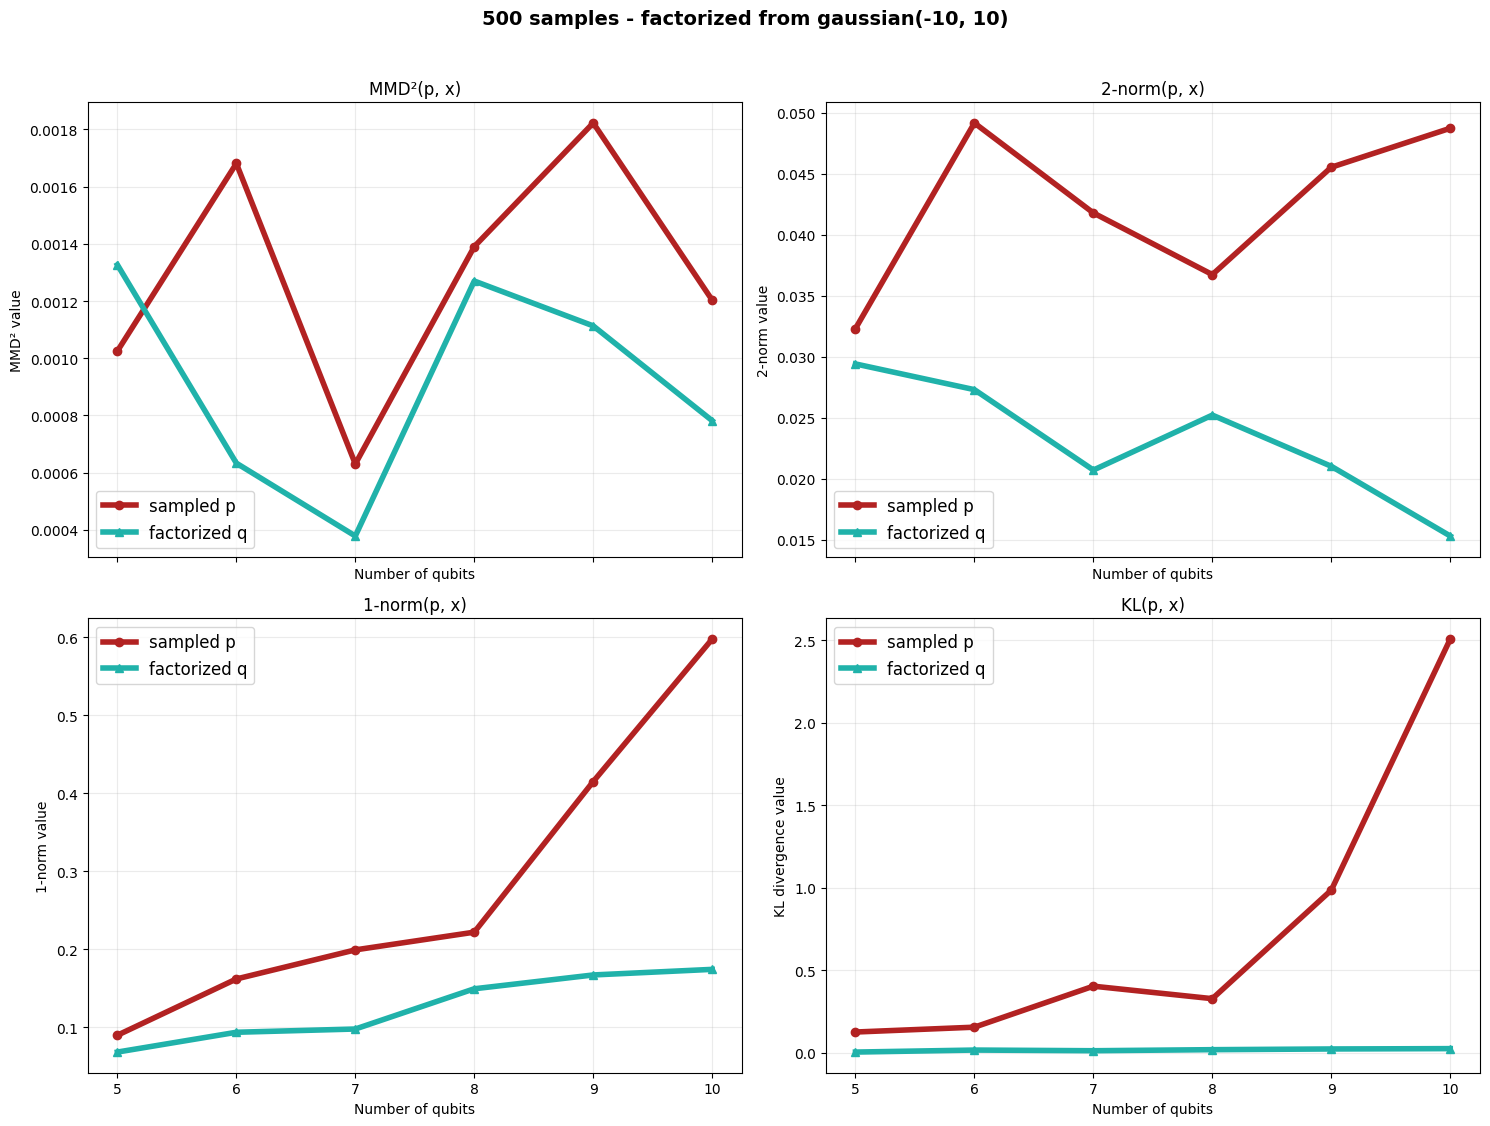

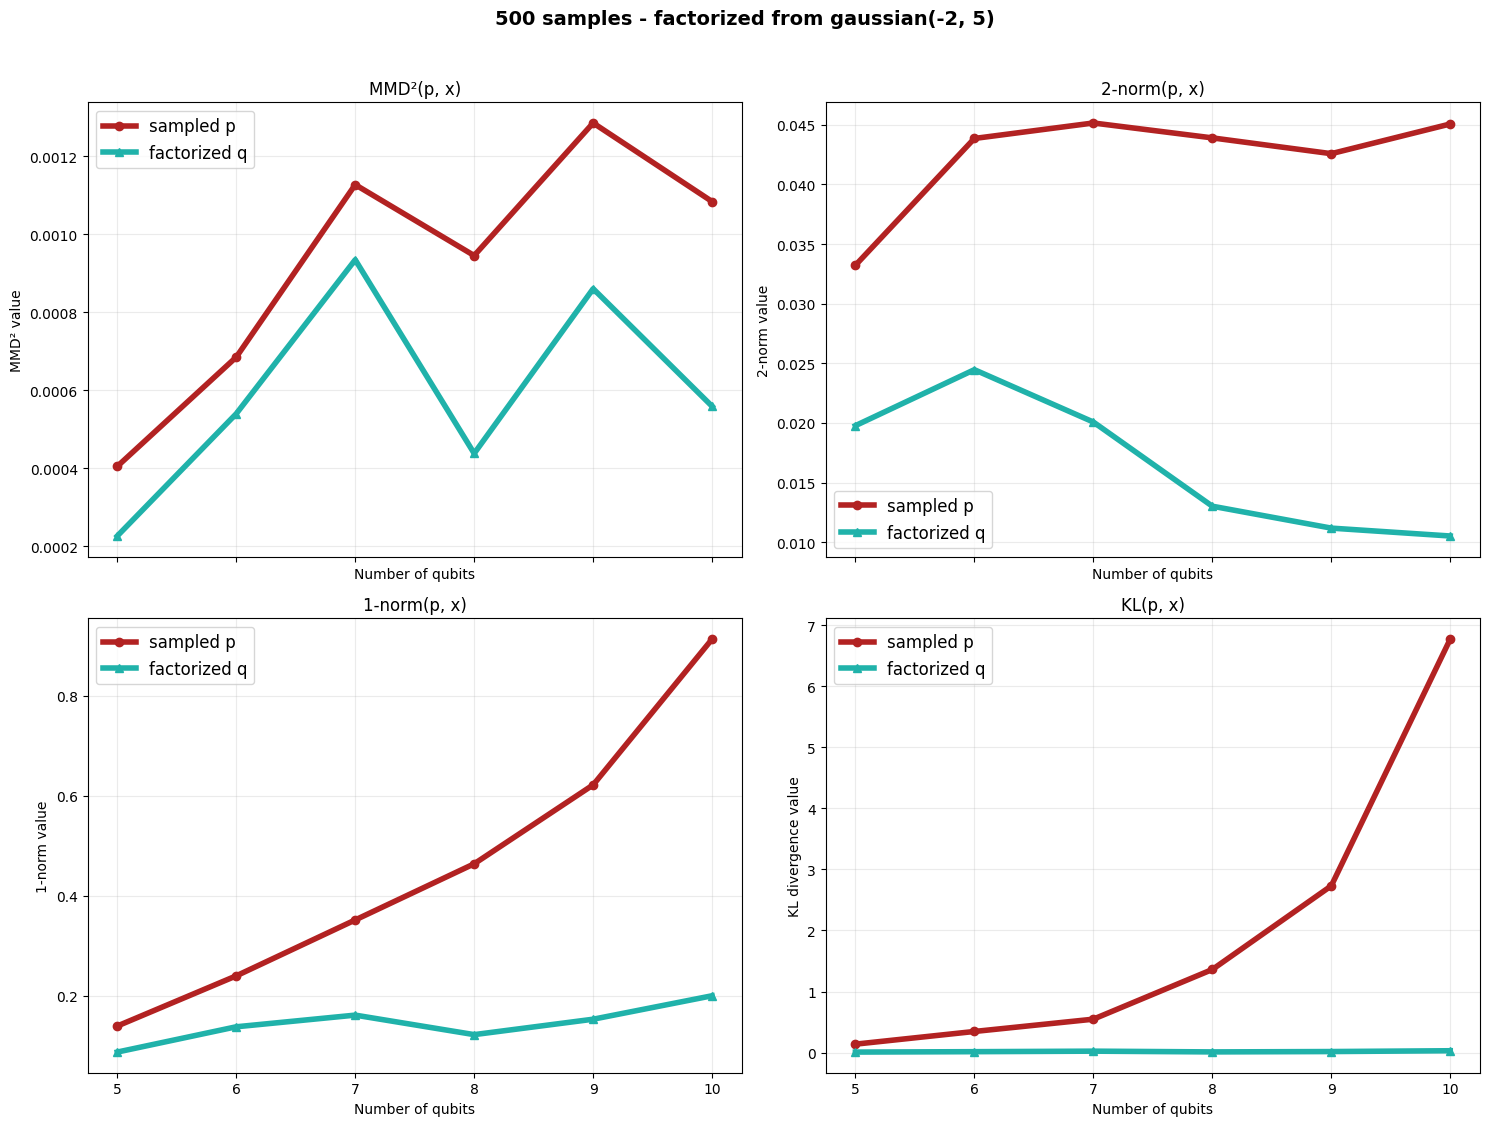

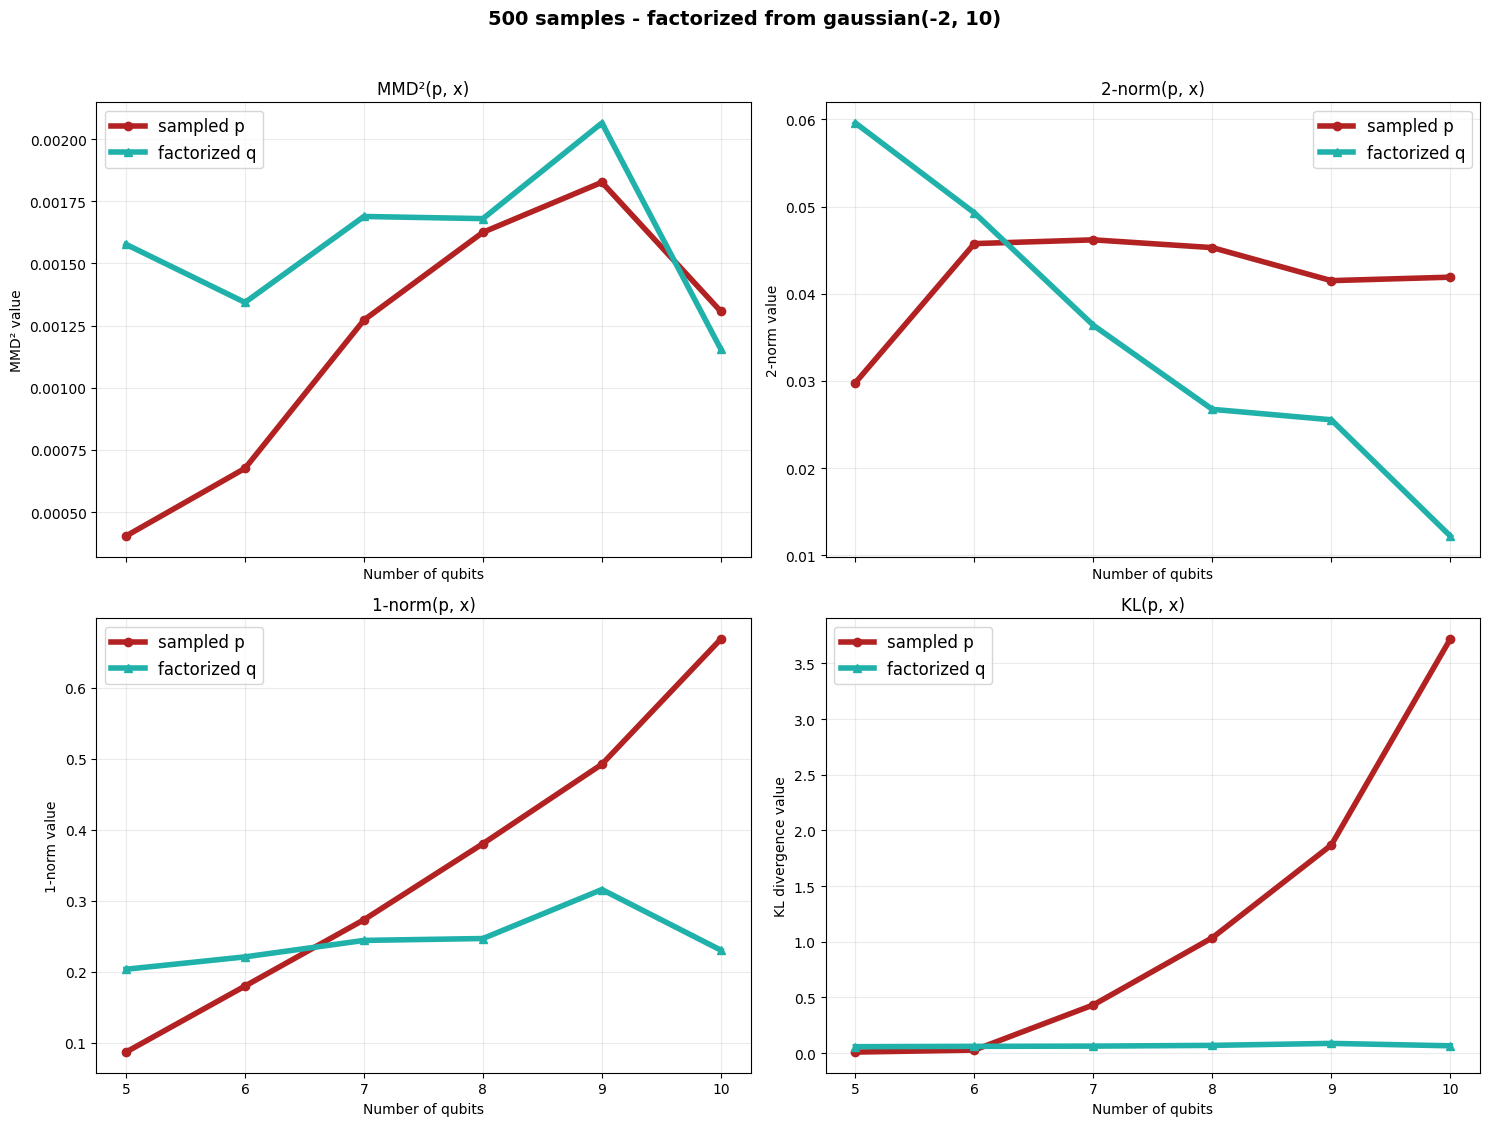

In [49]:
intervals = [(-5, 5), (-10, 10), (-2, 5), (-2, 10)]
n_qubits = 10
min_samples = 100
max_samples = 1000
n_samples = 500
qubit_values = range(min_qubits, max_qubits + 1)

for interval in intervals:
    mmd_ps_list = []
    mmd_pf_list = []
    mmd_pq_list = []

    two_ps_list = []
    two_pf_list = []
    two_pq_list = []

    one_ps_list = []
    one_pf_list = []
    one_pq_list = []

    kl_ps_list = []
    kl_pf_list = []
    kl_pq_list = []

    for n in qubit_values:
        p = discretized_normal_probability(interval, 2**n)
        p = match_mmd_optimal(p, sigma=0.2 * n, hw_min=1, hw_max=3)

        samples = np.random.default_rng().choice(2**n, size=n_samples, p=p)
        p_s = np.bincount(samples, minlength=2**n) / len(samples)

        q = match_mmd_optimal(p_s, sigma=0.2 * n, hw_min=1, hw_max=3)
        f = np.asarray(match_first_order(p_s))

        mmd_ps_list.append(mmd_squared(p, p_s, sigma=0.2 * n))
        mmd_pf_list.append(mmd_squared(p, f, sigma=0.2 * n))
        mmd_pq_list.append(mmd_squared(p, q, sigma=0.2 * n))

        two_ps_list.append(two_norm(p, p_s))
        two_pf_list.append(two_norm(p, f))
        two_pq_list.append(two_norm(p, q))

        one_ps_list.append(one_norm(p, p_s))
        one_pf_list.append(one_norm(p, f))
        one_pq_list.append(one_norm(p, q))

        kl_ps_list.append(kl_divergence(p, p_s))
        kl_pf_list.append(kl_divergence(p, f))
        kl_pq_list.append(kl_divergence(p, q))

    fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)

    x = list(qubit_values)

    metric_specs = [
        (axes[0, 0], mmd_ps_list, mmd_pf_list, mmd_pq_list, "MMD²", "MMD²(p, x)", "MMD² value"),
        (axes[0, 1], two_ps_list, two_pf_list, two_pq_list, "2-norm", "2-norm(p, x)", "2-norm value"),
        (axes[1, 0], one_ps_list, one_pf_list, one_pq_list, "1-norm", "1-norm(p, x)", "1-norm value"),
        (axes[1, 1], kl_ps_list, kl_pf_list, kl_pq_list, "KL", "KL(p, x)", "KL divergence value"),
    ]

    for ax, ys_ps, ys_pf, ys_pq, _, title, ylabel in metric_specs:
        ax.plot(x, ys_ps, label="sampled p", color=colors["ps"], linewidth=line_width, marker="o")
        # ax.plot(x, ys_pf, label="first-order", color=colors["pf"], linewidth=line_width, marker="s")
        ax.plot(x, ys_pq, label="factorized q", color=colors["pq"], linewidth=line_width, marker="^")
        ax.set_title(title)
        ax.set_xlabel("Number of qubits")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=12)

    a, b = interval
    fig.suptitle(
        f"{n_samples} samples - factorized from gaussian({a}, {b})",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    fig.tight_layout()
    fig.savefig(f"sampling_exp_qubits_{a}_{b}.png", dpi=300, bbox_inches="tight")